## Purpose
The purpose is to compare social and paid search as marketing channels to understand how they perform relative to each other to help drive marketing decision making.

## Outline
* Create the database from the csv files, luckily the headers are already formatted in a SQL query friendly way (column_name rather than Column Name, e.g.)
* Compare the marketing channels on the following:
** Conversion Rate
** Days to close a deal
** Revenue Drive (a bit flawed so it only can say which one drew more revenue rather than a specific number)
* Use statistical tests to confirm the significance and effect size.

In [1]:
import sqlite3 as sql
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
con = sql.connect("marketing.db")
cur = con.cursor()

In [3]:
def get_table_name(file: str) -> str:
    """takes in a file name of the form prefix_filename_suffix.extension and returns filename to be used as the name of the table, e.g. data/olist_customers_dataset.csv returns customers
    if the filename is made up of multiple words separated by '_' it will return an _ separated filename."""
    file_without_extension = file.split('.')[0]
    table_name_list = file_without_extension.split('_')[1:-1]
    table_name = '_'.join(table_name_list)
    return table_name

In [4]:
data_directory = os.getcwd() + "\\data"

for file in os.listdir(data_directory):
    df = pd.read_csv("data/" + file)

    table_name = get_table_name(file)

    df.to_sql(
    table_name,
    con,
    if_exists="replace",
    index=False
    )

This is to check to make sure the table structure matches the expected one.

In [5]:
query = "SELECT name FROM sqlite_master WHERE type='table';"
cur.execute(query)
tables = cur.fetchall()
tables

[('closed_deals',),
 ('customers',),
 ('geolocation',),
 ('marketing_qualified_leads',),
 ('orders',),
 ('order_items',),
 ('order_payments',),
 ('order_reviews',),
 ('products',),
 ('sellers',)]

In [6]:
columnDict = {}

for i,table in enumerate(tables):
    query = "SELECT * FROM %s;" % table
    cur.execute(query)
    cols = list(cur.description)
    valuelist = []
    for j, col in enumerate(cols):
        collist = list(col)
        valuelist.append(collist[0])
    columnDict[table] = valuelist

columnDict

{('closed_deals',): ['mql_id',
  'seller_id',
  'sdr_id',
  'sr_id',
  'won_date',
  'business_segment',
  'lead_type',
  'lead_behaviour_profile',
  'has_company',
  'has_gtin',
  'average_stock',
  'business_type',
  'declared_product_catalog_size',
  'declared_monthly_revenue'],
 ('customers',): ['customer_id',
  'customer_unique_id',
  'customer_zip_code_prefix',
  'customer_city',
  'customer_state'],
 ('geolocation',): ['geolocation_zip_code_prefix',
  'geolocation_lat',
  'geolocation_lng',
  'geolocation_city',
  'geolocation_state'],
 ('marketing_qualified_leads',): ['mql_id',
  'first_contact_date',
  'landing_page_id',
  'origin'],
 ('orders',): ['order_id',
  'customer_id',
  'order_status',
  'order_purchase_timestamp',
  'order_approved_at',
  'order_delivered_carrier_date',
  'order_delivered_customer_date',
  'order_estimated_delivery_date'],
 ('order_items',): ['order_id',
  'order_item_id',
  'product_id',
  'seller_id',
  'shipping_limit_date',
  'price',
  'freight_

This seems to check out with the csv files.

## Exploring the Two Marketing Channels

In [7]:
query = """
SELECT
    origin,
    COUNT(origin) as count
FROM marketing_qualified_leads
GROUP BY origin
ORDER BY count DESC
"""
cur.execute(query)
cur.fetchall()

[('organic_search', 2296),
 ('paid_search', 1586),
 ('social', 1350),
 ('unknown', 1099),
 ('direct_traffic', 499),
 ('email', 493),
 ('referral', 284),
 ('other', 150),
 ('display', 118),
 ('other_publicities', 65),
 (None, 0)]

Paid search and social are two prominent origins with similar counts so I'll do those do. I will check to see how many of the Marketing Qualified Leads for both also show up on closed deals which helps determine their effectiveness.

In [8]:
query = """ 
SELECT
    mql.origin,
    COUNT(mql.mql_id) as total_leads,
    COUNT(cd.mql_id) as converted_leads,
    ROUND(COUNT(cd.mql_id) * 1.0 / COUNT(mql.mql_id), 4) as conversion_rate
FROM marketing_qualified_leads as mql
LEFT JOIN closed_deals as cd ON mql.mql_id = cd.mql_id
WHERE mql.origin IN ('social', 'paid_search')
GROUP BY mql.origin
"""
cur.execute(query)
lead_results = cur.fetchall()

I want to run a two-proportions z-test to A/B test the paid_search and social marketing origins for customers, and see if there is a statistically signficant difference between the two channels.

In [9]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

In [10]:
lead_results

[('paid_search', 1586, 195, 0.123), ('social', 1350, 75, 0.0556)]

In [11]:
paid_search_converted = lead_results[0][2]
social_converted = lead_results[1][2]

paid_search_total = lead_results[0][1]
social_total = lead_results[1][1]

paid_search_rate = lead_results[0][3]
social_rate = lead_results[1][3]

In [12]:
converted = np.array([paid_search_converted, social_converted])
total = np.array([paid_search_total, social_total])

z_value, p_value = proportions_ztest(converted, total)

print(f"Z-statistic: {z_value:.4f}")
print(f"P-value: {p_value:.4f}")

# a p-value of 0.05 is a typical chosen cutoff
alpha = 0.05
if p_value < alpha:
    print("Result: Statistically significant difference in conversion rates")
else:
    print("Result: No statistically significant difference detected")

Z-statistic: 6.2982
P-value: 0.0000
Result: Statistically significant difference in conversion rates


In [13]:
p_value

np.float64(3.011928516301947e-10)

The result has large statistical significance since it's a decimal preceded by 9 zeroes. This means there is a signficant difference between social and paid search, but it's not clear how large the difference is (for which I will use Cohen's h to estimate the effect size, and confidence intervals to see how confident I am in this), and how this change with time (for which I will do a time-based analysis to look at seasonality, trends in coversion rate and time to close a deal).

### Cohen's h and Confidence Intervals

As mentioned, I want to use Cohen's h to measure the distance between these two proportions, mainly I want to see is the difference is "small", "medium" or "large" using the traditional thresholds: 0.2, 0.5, and 0.8 respectively. Next I want to use confidence intervals to see the range expected for the conversion rates to fall in, and if the two intervals do not overlap with each other than the effect is much stronger.

In [14]:
from statsmodels.stats.proportion import proportion_effectsize

h = proportion_effectsize(paid_search_rate, social_rate)
f"Cohen's h: {h:.4f}"

"Cohen's h: 0.2406"

Confidence Intervals

In [15]:
from statsmodels.stats.proportion import proportion_confint

conf_int_paid_search = proportion_confint(paid_search_converted, paid_search_total, alpha=0.05)
conf_int_social = proportion_confint(social_converted, social_total, alpha=0.05)

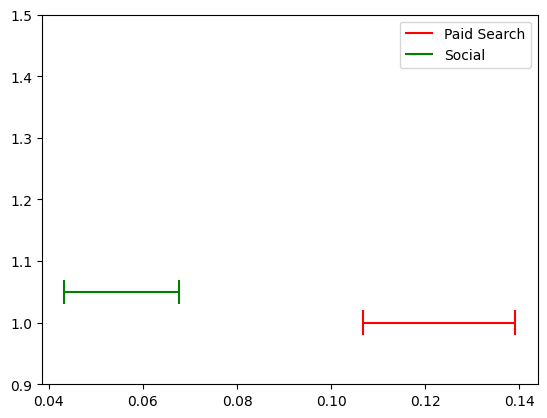

In [16]:
ax = plt.subplot()
plt.hlines(1, conf_int_paid_search[0], conf_int_paid_search[1], color='r', label='Paid Search')
plt.hlines(1.05, conf_int_social[0], conf_int_social[1], color='g', label="Social")
plt.vlines(conf_int_paid_search[0], 1.02,0.98, color='r')
plt.vlines(conf_int_paid_search[1], 1.02,0.98, color='r')
plt.vlines(conf_int_social[0], 1.03,1.07, color='g')
plt.vlines(conf_int_social[1], 1.03,1.07, color='g')
ax.set_ylim(0.9, 1.5)
ax.legend()
plt.show()

The effect size is small, but the effect is statistically significant as the confidence intervals do not overlap, and the p value is incredibly small.

### Time-Series Analysis

In [17]:
query = """ 
SELECT
    mql.origin,
    MAX(mql.first_contact_date),
    MIN(mql.first_contact_date),
    MAX(cd.won_date),
    MIN(cd.won_date)    
FROM marketing_qualified_leads as mql
JOIN closed_deals as cd
    ON mql.mql_id = cd.mql_id
WHERE mql.origin IN ('social', 'paid_search')
GROUP BY mql.origin
"""
cur.execute(query)
cur.fetchall()

[('paid_search',
  '2018-05-31',
  '2017-08-01',
  '2018-11-12 19:17:25',
  '2017-12-11 18:07:26'),
 ('social',
  '2018-05-29',
  '2017-08-16',
  '2018-10-05 12:35:50',
  '2018-01-10 18:15:06')]

In [18]:
query = """ 
SELECT
    mql.origin,
    STRFTIME('%Y-%m', mql.first_contact_date) as month,
    COUNT(mql.mql_id) as total_leads,
    COUNT(cd.mql_id) as converted_leads
FROM marketing_qualified_leads mql
LEFT JOIN closed_deals cd ON mql.mql_id = cd.mql_id
WHERE mql.origin IN ('social', 'paid_search')
GROUP BY mql.origin, month
ORDER BY mql.origin, month
"""
cur.execute(query)
cur.fetchall()

[('paid_search', '2017-07', 56, 0),
 ('paid_search', '2017-08', 79, 3),
 ('paid_search', '2017-09', 64, 2),
 ('paid_search', '2017-10', 100, 7),
 ('paid_search', '2017-11', 70, 6),
 ('paid_search', '2017-12', 35, 2),
 ('paid_search', '2018-01', 170, 20),
 ('paid_search', '2018-02', 212, 43),
 ('paid_search', '2018-03', 262, 39),
 ('paid_search', '2018-04', 272, 43),
 ('paid_search', '2018-05', 266, 30),
 ('social', '2017-07', 12, 0),
 ('social', '2017-08', 45, 3),
 ('social', '2017-09', 56, 0),
 ('social', '2017-10', 52, 2),
 ('social', '2017-11', 95, 4),
 ('social', '2017-12', 39, 0),
 ('social', '2018-01', 162, 8),
 ('social', '2018-02', 156, 15),
 ('social', '2018-03', 139, 16),
 ('social', '2018-04', 325, 16),
 ('social', '2018-05', 269, 11)]

In [19]:
df = pd.read_sql_query(query, con)

df["monthly_conversion_rate"] = df["converted_leads"] / df["total_leads"]

df = df.sort_values("month")
df["cumulative_converted_leads"] = df.groupby("origin")["converted_leads"].cumsum()
df["cumulative_total_leads"] = df.groupby("origin")["total_leads"].cumsum()
df["cumulative_conversion_rate"] = df["cumulative_converted_leads"] / df["cumulative_total_leads"]


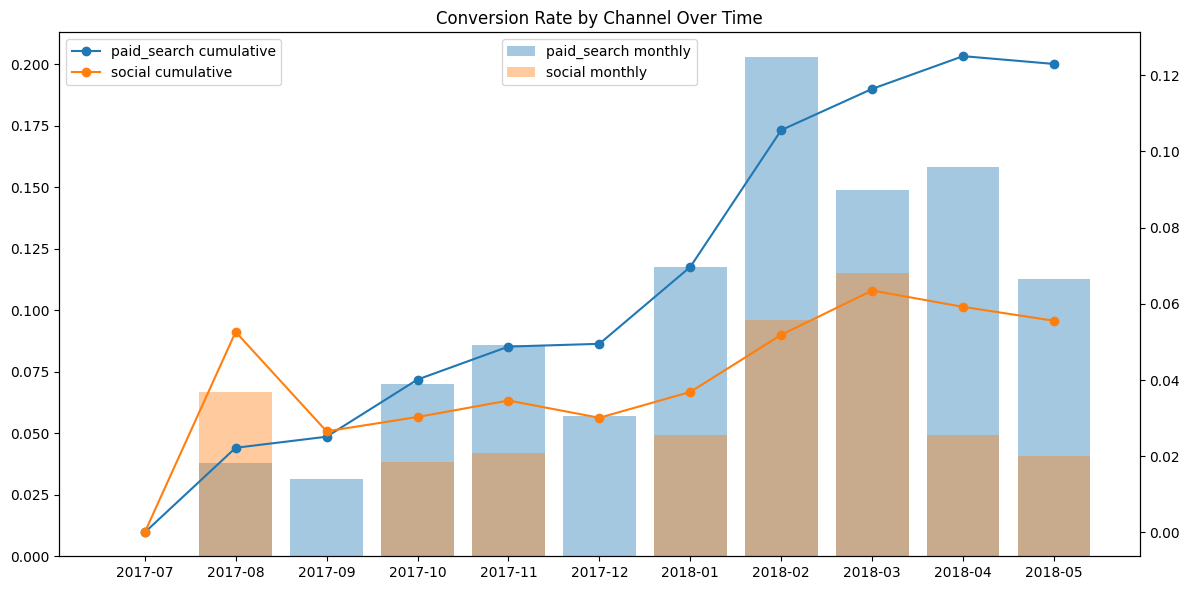

In [20]:
fig, ax1 = plt.subplots(figsize=(12, 6))

for origin in ['paid_search', 'social']:
    subset = df[df['origin'] == origin]
    ax1.bar(subset['month'], subset['monthly_conversion_rate'], alpha=0.4, label=f'{origin} monthly')

ax2 = ax1.twinx()
for origin in ['paid_search', 'social']:
    subset = df[df['origin'] == origin]
    ax2.plot(subset['month'], subset['cumulative_conversion_rate'],marker='o', label=f'{origin} cumulative')

plt.title('Conversion Rate by Channel Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
ax1.legend(loc="upper center")
ax2.legend()
plt.show()

The early period is fairly strange, but overall paid search performs better than social regardless of if its on a monthly, or cumulative scale. Unfortunately, It's a bit difficult to make definitive statements about seasonality since each month appears only once (June does not appear at all), and the early months are fairly volatile. Interestingly, 2018, is in general, a good period for both social and paid search conversion, where metrics are increasing.

There are some questions about this data, like why the jump in 2018 exists (a year of significant growth for Olist?), but ultimately A/B test remains significant.

Time to close: the time in between the start date in the marketing qualified leads table and the won date in the closed deals table.

In [21]:
query = """
SELECT
    mql.origin,
    AVG(JULIANDAY(cd.won_date) - JULIANDAY(mql.first_contact_date)) AS avg_days_to_close
FROM marketing_qualified_leads AS mql
JOIN closed_deals AS cd
    ON mql.mql_id = cd.mql_id
WHERE mql.origin IN ('social', 'paid_search')
GROUP BY mql.origin
"""
cur.execute(query)
cur.fetchall()

[('paid_search', 57.274347400283204), ('social', 61.61911018517489)]

The difference in days to close seem statistically insignificant but I want to check to be sure by using the Mann-Whitney U (the data turned out to be skewed), and find the effect size using rank-biserial correlation

I will then take the non-averaged days to close and use the t-test to make sure that result is significant or not.

In [22]:
from scipy.stats import mannwhitneyu

query = """
SELECT
    mql.origin,
    JULIANDAY(cd.won_date) - JULIANDAY(mql.first_contact_date) AS days_to_close
FROM marketing_qualified_leads AS mql
JOIN closed_deals AS cd
    ON mql.mql_id = cd.mql_id
WHERE mql.origin IN ('social', 'paid_search')
"""

df = pd.read_sql(query, con)

paid_search_days_to_close = df[df["origin"] == "paid_search"]["days_to_close"]
social_days_to_close = df[df["origin"] == "social"]["days_to_close"]

mannwhitneyu_score, p_value = mannwhitneyu(paid_search_days_to_close, social_days_to_close)

print(f"Mann-Whitney U value: {mannwhitneyu_score:.4f}")
print(f"P-value: {p_value:.4f}")

n1 = len(paid_search_days_to_close)
n2 = len(social_days_to_close)
r = 1 - (2 * mannwhitneyu_score) / (n1 * n2)
print(f"Rank-biserial correlation: {r:.4f}")


Mann-Whitney U value: 6056.0000
P-value: 0.0289
Rank-biserial correlation: 0.1718


The reason why I used Mann-Whitney U test is because the data is heavily skewed as seen below.

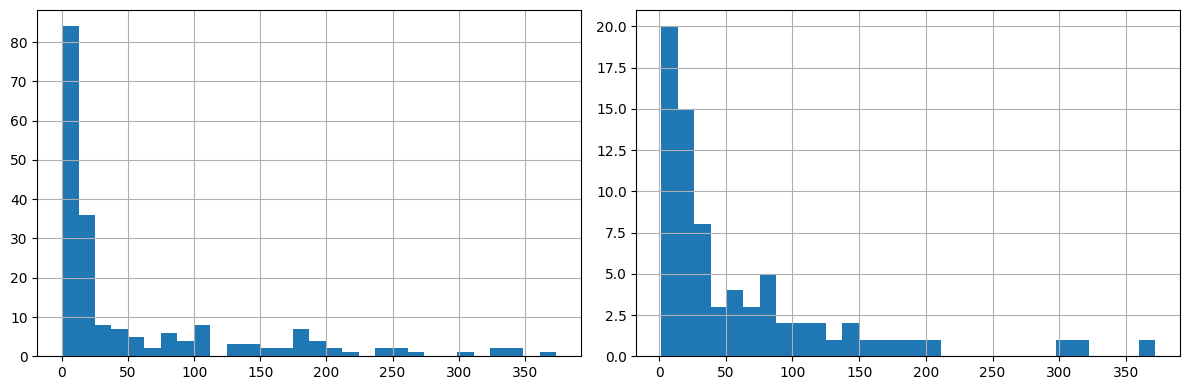

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
paid_search_days_to_close.hist(ax=axes[0], bins=30)
social_days_to_close.hist(ax=axes[1], bins=30)
plt.tight_layout()
plt.show()

Now to use rank-biserial to 

A large Mann-Whitney U value coupled with a statistically signficant value (p value < 0.05) means that the different is small but statistically significant which is what I expected, which is similar to the conversion rate result found via Cohen's h.

## Revenue Analysis

This revenue analysis is imperfect (joining on seller_id is an issue because each seller is an entity who may have multiple leads or orders) but it showcases a further avenue for analysis that showcases the value of a channel via revenue.

In [24]:
query = """
SELECT 
    mql.origin,
    COUNT(DISTINCT cd.seller_id) as seller_count,
    SUM(op.payment_value) as toal_revenue,
    SUM(op.payment_value) / COUNT(DISTINCT cd.seller_id) as revenue_per_seller
FROM marketing_qualified_leads as mql
JOIN closed_deals as cd ON mql.mql_id = cd.mql_id
JOIN order_items AS o ON cd.seller_id = o.seller_id
JOIN order_payments AS op ON o.order_id = op.order_id
WHERE mql.origin IN ('social', 'paid_search')
GROUP BY mql.origin
"""
cur.execute(query)
cur.fetchall()

[('paid_search', 101, 251088.18, 2486.021584158416),
 ('social', 31, 67671.6, 2182.9548387096775)]

The revenue difference is striking at first, but with the seller count and revenue per seller taken into account, it's another data point for the fact that the value difference is not massive but it exists.

## Data for Tableau

I want to get a few things for Tableau:
    1. Conversion rate - static and time series
    2. Days to Close
    3. Revenue Analysis
    4. Confidence Intervals (since it's typically better to just calculate them ahead of time)

In [25]:
query = """ 
SELECT
    mql.origin,
    STRFTIME('%Y-%m', mql.first_contact_date) AS month,
    COUNT(mql.mql_id) AS total_leads,
    COUNT(cd.mql_id) AS converted_leads,
    ROUND(COUNT(cd.mql_id) * 1.0 / COUNT(mql.mql_id), 4) AS conversion_rate
FROM marketing_qualified_leads AS mql
LEFT JOIN closed_deals AS cd ON mql.mql_id = cd.mql_id
WHERE mql.origin IN ('social', 'paid_search')
GROUP BY mql.origin, month
ORDER BY mql.origin, month
"""

df = pd.read_sql(query, con)

df["confint_lower"], df["confint_upper"] = proportion_confint(df["converted_leads"], df["total_leads"], alpha=0.05)

df.to_csv("tableau data\\conversion_rate.csv", index=False)

In [26]:
query = """
SELECT
    mql.origin,
    mql.mql_id,
    JULIANDAY(cd.won_date) - JULIANDAY(mql.first_contact_date) AS days_to_close
FROM marketing_qualified_leads AS mql
JOIN closed_deals AS cd
    ON mql.mql_id = cd.mql_id
WHERE mql.origin IN ('social', 'paid_search')
"""

df = pd.read_sql(query, con)
df.to_csv("tableau data\\days_to_close.csv", index=False)

In [27]:
query = """
SELECT 
    mql.origin,
    COUNT(DISTINCT cd.seller_id) as seller_count,
    STRFTIME('%Y-%m', mql.first_contact_date) AS month,
    SUM(op.payment_value) as toal_revenue,
    SUM(op.payment_value) / COUNT(DISTINCT cd.seller_id) as revenue_per_seller
FROM marketing_qualified_leads as mql
JOIN closed_deals as cd ON mql.mql_id = cd.mql_id
JOIN order_items AS o ON cd.seller_id = o.seller_id
JOIN order_payments AS op ON o.order_id = op.order_id
WHERE mql.origin IN ('social', 'paid_search')
GROUP BY mql.origin, month
ORDER BY mql.origin, month
"""

df = pd.read_sql(query, con)
df.to_csv("tableau data\\revenue_analysis.csv", index=False)

In [29]:
df.groupby("origin").sum()

,seller_count,month,toal_revenue,revenue_per_seller
origin,,,,
paid_search,101,2017-082017-102017-112017-122018-012018-022018...,251088.18,20858.824222
social,31,2017-112018-012018-022018-032018-042018-05,67671.60,11412.517417


## Conclusion

The result of the A/B test is that there is definitely a difference in the performance of social and paid search, but the difference is small per the Cohen's h, Mann-Whitney U value, and even the revenue analysis.